# Inverse Problems Exercises: 2023s s02 (non-sc)
https://www.umm.uni-heidelberg.de/miism/

## Notes
* Please **DO NOT** change the name of the `.ipynb` file. 
* Please **DO NOT** import extra packages to solve the tasks. 
* Please put the `.ipynb` file directly into the `.zip` archive without any intermediate folder. 

## Please provide your personal information
* full name (Name): 

Jan Benda

## I06: Convolution theorem

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.linalg import toeplitz

In [2]:
from urllib.request import urlopen
import matplotlib.image as mpimg

# create a file-like object from the url
file_input = urlopen('https://upload.wikimedia.org/wikipedia/commons/thumb/1/12/Grayscale_Cat.jpg/320px-Grayscale_Cat.jpg')

# load the input image
image_input = mpimg.imread(file_input, 'jpg')

# pick the central line as signal f
f_true = image_input[image_input.shape[0] // 2, :]

<class 'urllib.error.URLError'>: <urlopen error unknown url type: https>

### Imaging model
The imaging model can be represented by
$$
g = h \otimes f_\text{true} = Af_\text{true} = \mathcal{F}^{-1}\{ \mathcal{F}\{h\} \mathcal{F}\{f_\text{true}\} \} .
$$
* $f_\text{true}$ is the input signal
* $h$ is the point spread function (kernel)
* $\otimes$ is the convolution operator
* $A$ is the Toeplitz matrix of $h$
* $\mathcal{F}$ and $\mathcal{F}^{-1}$ are the Fourier transform operator and inverse Fourier transform operator
* $g$ is the output signal

### Gaussian kernel
Implement the Gaussian kernel function $h$
* Given the standard deviation of the Gaussian $\sigma_h$
* Given the kernel size $s_h$
* Define the origin of the kernels in the middle of the array
* Normalize the kernel, i.e. the sum of the kernel elements equals to $1$
* Implement the function `get_gaussian_1d()` (using `numpy.array`)
  
Generate the Gaussian kernels
* Parameter options of $(\sigma_h, s_h)$
  - (1, 5)
  - (4, 21)
  - (7, 35)
  - (20, 35)
* Save the outputs in the variable `list_h_psf` (as `list` of `numpy.array`)

Display the result
* Plot the kernels in `list_h_psf` in the same order of the parameter options in the axes `ax`
* Show the legend in the axes `ax`

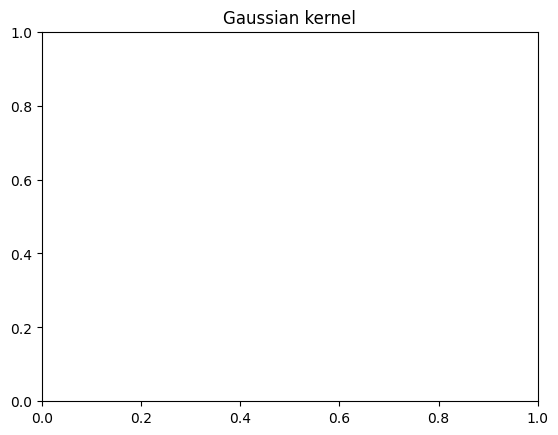

<class 'NameError'>: name 'list_h_pfs' is not defined

In [3]:
######################
# The second block raised an exception "URLError: <urlopen error unknown url type: https>" upon opening the URL
# This code compensates the error by opening the file from local folder
if False:
    # load the input image
    image_input = mpimg.imread('320px-Grayscale_Cat.jpg', 'jpg')

    # pick the central line as signal f
    f_true = image_input[image_input.shape[0] // 2, :]
#########################




def get_gaussian_1d(sigma, kernel_size):
    """ Returns a gaussian kernel, with a specified kernel size.
    Low pass (blurring) kernel.

    :param sigma: Standard deviation of the Gaussian function.
    :param kernel_size: Kernel size.
    :returns: normalized Gaussian kernel.
    """
    x = np.linspace(-(kernel_size-1)/2,(kernel_size-1)/2,kernel_size)
    y = np.exp(-x**2/(2*sigma))
    y /= np.sum(y)
    return y
    
#raise NotImplementedError()

fig, ax = plt.subplots()  # Create a figure and an axes.
ax.set_title('Gaussian kernel')

psf_param = [(1,5),(4,21),(7,35),(20,35)]
list_h_psf = [get_gaussian_1d(psf[0], psf[1]) for psf in psf_param]

for i in range(len(psf_param)):
    x = np.linspace(-(psf_param[i][1]-1)/2,(psf_param[i][1]-1)/2,psf_param[i][1])
    ax.plot(x,list_h_pfs[i], label =r'$\sigma_h = $'+str(psf_param[i][0])+", "+r'$s_h = $'+str(psf_param[i][1]))
    
ax.legend()

#raise NotImplementedError()

In [4]:
# This cell contains hidden tests.


In [5]:
# This cell contains hidden tests.


### Convolution operation
Convolution with the Gaussian kernels $g = h \otimes f_\text{true}$ (using `numpy.convolve()`)
* Apply the kernels in `list_h_psf` to `f_true`
* Return the outputs with the same length as `f_true`
* Save the outputs in the variable `list_g_cov` (as `list` of `numpy.array`)

Display the result
* Plot the outputs in `list_g_cov` in the same order of the parameter options in the axes `ax`
* Plot `f_true` in the axes `ax` (after `list_g_cov`)
* Show the legend in the axes `ax`

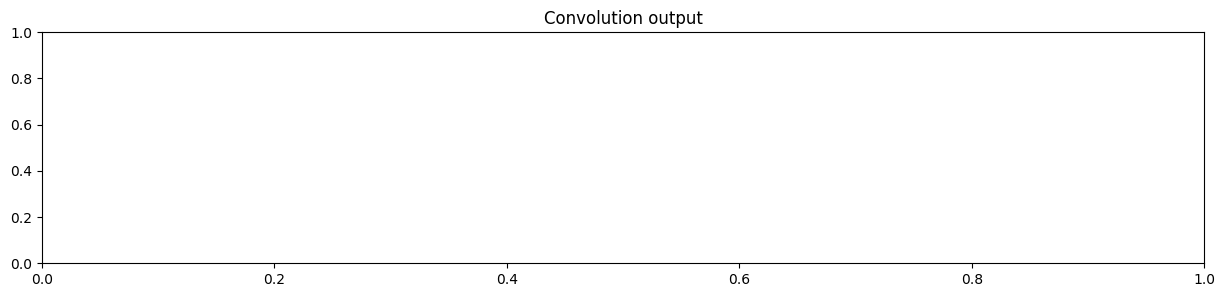

<class 'NameError'>: name 'f_true' is not defined

In [6]:
fig, ax = plt.subplots(1, 1, figsize = (15, 3))  # Create a figure and an axes.
ax.set_title('Convolution output')

list_g_cov = []

for psf in list_h_psf:
    list_g_cov.append(np.convolve(f_true, psf,"same"))
    
for i in range(len(psf_param)):
    ax.plot(list_g_cov[i], label ="convolution parameters "+r'$\sigma_h = $'+str(psf_param[i][0])+", "+r'$s_h = $'+str(psf_param[i][1]))
    
ax.legend()
    
#raise NotImplementedError()

In [7]:
# This cell contains hidden tests.


### Toeplitz matrix
See: https://en.wikipedia.org/wiki/Toeplitz_matrix#Discrete_convolution

Implement the Toeplitz matrix $A$ corresponding to $h$ (using `scipy.linalg.toeplitz()` optionally)
  - Given $h$
  - Given signal size $s_f$
  - Take the zero-padding option, i.e the input array values outside the bounds of the array are assigned $0$
  - Implement the function `get_convolution_matrix()` (using `numpy.array`)
  
Generate the Toeplitz matrices
* Return the outputs of each kernel in `list_h_psf` for `f_true`
* Save the outputs in the variable `list_A_psf` (as `list` of `numpy.array`)

Display the result
* Plot the matrices in `list_A_psf` as grayscale images in the same order of the parameter options in the subplots of `axs`
* Add proper titles to the subplots of `axs`

In [8]:
def get_convolution_matrix(kernel, n):
    """ Create a Toeplitz matrix for discrete 1d convolution.
    :param kernel: 1d convolution kernel.
    :param n: Size of the signal, which should be convolved with the kernel.
    :returns: 2d matrix of size (n,n) for convolution by matrix-vector multiplication.
    """
    high_toeplitz = toeplitz(np.r_[kernel,np.zeros(n-1)],np.zeros(n))
    r_number = np.shape(high_toeplitz)[0]
    to_trim = int((r_number - n)/2)
    
    return high_toeplitz[to_trim:-to_trim,:]
    
list_A_psf = []
for kernel in list_h_psf:
    list_A_psf.append(get_convolution_matrix(kernel, np.shape(f_true)[0]))

#raise NotImplementedError()

fig, axs = plt.subplots(2, 2, figsize=(10, 10))
fig.suptitle('Toeplitz matrix')

for x in (0,1):
    for y in (0,1):
        i = 2*x+y
        axs[x][y].imshow(list_A_psf[i], cmap=plt.get_cmap('gray'))
        axs[x][y].title.set_text("with parameters "+r'$\sigma_h = $'+str(psf_param[i][0])+", "+r'$s_h = $'+str(psf_param[i][1]))
        
    

<class 'NameError'>: name 'f_true' is not defined

In [9]:
# This cell contains hidden tests.


In [10]:
# This cell contains hidden tests.


### Convolution with the Toeplitz matrix 
Convolution with the Toeplitz matrix $g = Af_\text{true}$
* Apply the Toeplitz matrix in `list_A_psf` to `f_true`
* Save the outputs in the variable `list_g_toe` (as `list` of `numpy.array`)

Display the result
* Plot the outputs in `list_g_toe` in the same order of the parameter options in the axes `ax`
* Plot `f_true` in the axes `ax` (after `list_g_toe`)
* Show the legend in the axes `ax`

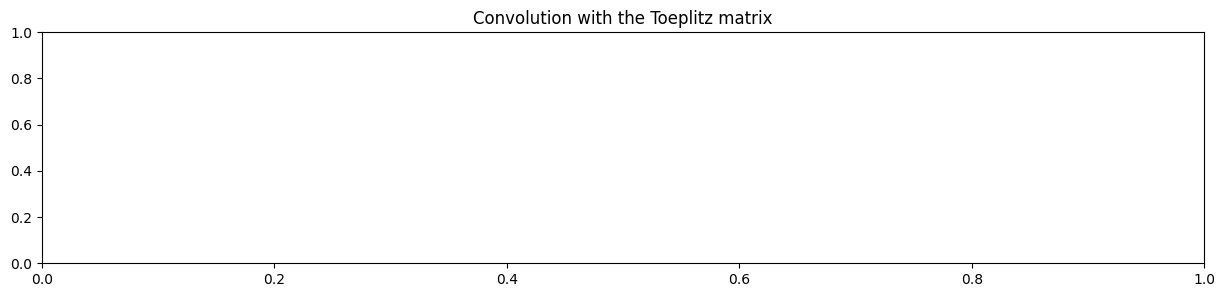

<class 'IndexError'>: list index out of range

In [11]:
fig, ax = plt.subplots(1, 1, figsize = (15, 3))  # Create a figure and an axes.
ax.set_title('Convolution with the Toeplitz matrix')

list_g_toe = []
for A in list_A_psf:
    list_g_toe.append(A @ f_true)

for i in range(len(psf_param)):
    ax.plot(list_g_toe[i], label ="matrix parameters "+r'$\sigma_h = $'+str(psf_param[i][0])+", "+r'$s_h = $'+str(psf_param[i][1]))
    
ax.legend()
#raise NotImplementedError()

In [12]:
# This cell contains hidden tests.


In [13]:
# This cell contains tests.

for g_cov, g_toe in zip(list_g_cov, list_g_toe):
    np.testing.assert_almost_equal(g_cov, g_toe) # zero-padding

### Question: Matrix expression
* What's the advantage to use the matrix expression of convolution $g = Af_\text{true}$ for inverse problems?

It is easier to solve the inverse convolution problem, since we only need to invert the matrix $A$.

### Fourier transform
Fourier transform of the Gaussian kernels $\mathcal{F}\{h\}$ (using `numpy.fft.fft()`)
* Pad zeros to both sides of the kernels in `list_h_psf`
* Adjust the kernels as long as `f_true`
* Shift the origin of the kernels to the first element of the array
* Apply the Fourier transform to the shifted padded kernels
* Save the outputs in the variable `list_h_fft` (as `list` of `numpy.array`)

Display the result
* Plot the absolute value of the outputs in `list_h_fft` in the same order of the parameter options in the axes `ax`
* Plot the outputs properly in the frequency domain
* Show the legend in the axes `ax`

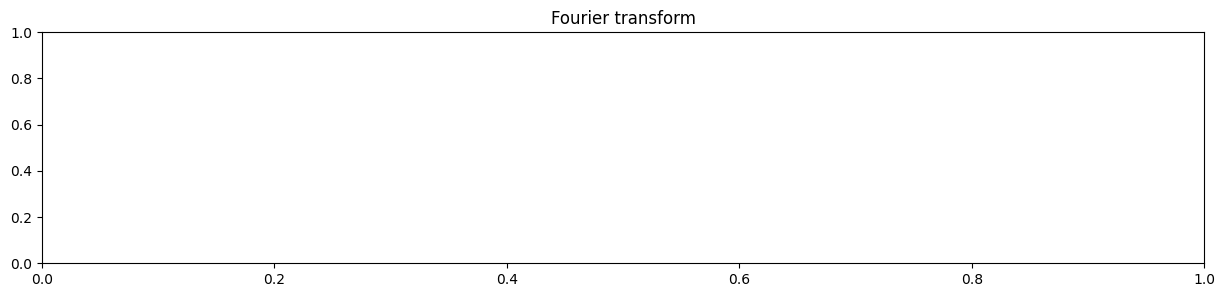

<class 'NameError'>: name 'f_true' is not defined

In [14]:
fig, ax = plt.subplots(1, 1, figsize = (15, 3))  # Create a figure and an axes.
ax.set_title('Fourier transform')

f_len = len(f_true)
list_h_fft = []

for ker in list_h_psf:
    to_padd = int((f_len-np.shape(ker)[0])/2)
    new_ker = np.r_[np.zeros(to_padd),ker,np.zeros(to_padd+1)]
    
    to_roll = int(np.shape(new_ker)[0]/2-1)
    new_ker = np.roll(new_ker,-to_roll)
    
    new_ker = np.fft.fft(new_ker)
    
    list_h_fft.append(new_ker)
    
for i in range(len(psf_param)):
    ax.plot(abs(list_h_fft[i]), label ="FFT of gaussian with parameters "+r'$\sigma_h = $'+str(psf_param[i][0])+", "+r'$s_h = $'+str(psf_param[i][1]))
    
plt.legend()


In [15]:
# This cell contains hidden tests.


In [16]:
# This cell contains hidden tests.


### Convolution with the Fourier transform
Convolution with the Fourier transform $g = \mathcal{F}^{-1}\{ \mathcal{F}\{h\} \mathcal{F}\{f_\text{true}\} \}$
* Apply the transformed kernels in `list_h_fft` to `f_true`
* Return the absolute value of the inverse transform
* Save the outputs in the variable `list_g_dft` (as `list` of `numpy.array`)

Display the result
* Plot the outputs in `list_g_dft` in the same order of the parameter options in the axes `ax`
* Plot `f_true` in the axes `ax` (after `list_g_dft`)
* Show the legend in the axes `ax`

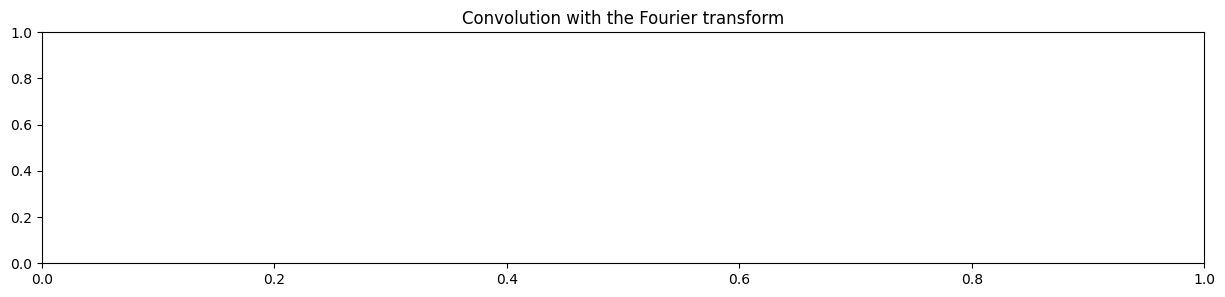

<class 'NameError'>: name 'f_true' is not defined

In [17]:
fig, ax = plt.subplots(1, 1, figsize = (15, 3))  # Create a figure and an axes.
ax.set_title('Convolution with the Fourier transform')

f_fft = np.fft.fft(f_true)

list_g_dft = []
for fft in list_h_fft:
    list_g_dft.append(abs(np.fft.ifft(fft*f_fft)))

for i in range(len(psf_param)):
    ax.plot(list_g_dft[i], label ="FFT convolution parameters "+r'$\sigma_h = $'+str(psf_param[i][0])+", "+r'$s_h = $'+str(psf_param[i][1]))
    
plt.legend()
#raise NotImplementedError()

In [18]:
# This cell contains hidden tests.


In [19]:
# This cell contains tests.

for g_cov, g_dft in zip(list_g_cov, list_g_dft):
    np.testing.assert_almost_equal(g_cov[40:-40], g_dft[40:-40]) # with boundary effects

<class 'NameError'>: name 'list_g_dft' is not defined

### Question: Fourier transform
* What's the advantage to use the Fourier transform for convolution $\mathcal{F}\{g\} = \mathcal{F}\{h\} \mathcal{F}\{f_\text{true}\}$ for inverse problems?

If we want to reverse the convolution to reconstruct original data, we just need to divide by $\mathcal{F}\{h\}$, to obtain $f_\text{true}=\mathcal{F}^{-1}\{\frac{\mathcal{F}\{g\}}{\mathcal{F}\{h\}}\}$